# Decision Tree Classification

## Objective

The objective of this notebook is to build a Decision Tree Classification model that predicts an employee's salary category.

In this notebook, you will learn how to:

- Load the dataset
- Handle missing values
- Define features and target variable
- Split the dataset into training and testing sets
- Train a Decision Tree Classification model
- Make predictions
- Evaluate the model using classification metrics
- Visualize the Decision Tree

In [26]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

**Step 1: Mount Google Drive**

Google Drive is mounted to access the dataset and save the trained model.

In [27]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Step 2: Load the Dataset**

Load the Employee Salary Classification dataset from Google Drive.

In [28]:
df = pd.read_excel(
    "/content/drive/MyDrive/Datasets/Salary_Logistic_Regression_Multiclass_Classification_Dataset.xlsx"
)

df

,Experience_Years,Education_Level,Age,Monthly_Salary_PKR,Salary_Category
0,1,12.0,22.0,40000,0
1,2,12.0,23.0,45000,0
2,2,14.0,24.0,50000,0
3,3,14.0,25.0,58000,0
4,3,NaN,26.0,65000,0
5,4,16.0,27.0,70000,0
6,4,16.0,28.0,74000,0
7,5,16.0,29.0,82000,1
8,5,18.0,30.0,90000,1
9,6,18.0,31.0,98000,1


**Step 3: Handle Missing Values**

Check whether the dataset contains missing values.

If any missing values are found, replace them with the median value of the respective column.

In [29]:
print("\nBefore Filling Missing Values")
print(df.isnull().sum())

df["Education_Level"] = df["Education_Level"].fillna(
    df["Education_Level"].median()
)

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

print("\nAfter Filling Missing Values")

print(df.isnull().sum())


Before Filling Missing Values
Experience_Years      0
Education_Level       2
Age                   1
Monthly_Salary_PKR    0
Salary_Category       0
dtype: int64

After Filling Missing Values
Experience_Years      0
Education_Level       0
Age                   0
Monthly_Salary_PKR    0
Salary_Category       0
dtype: int64


**Step 4: Define Features and Target Variable**

The independent variables are:

- Experience Years
- Education Level
- Age

The dependent variable is:

- Salary Category

Salary Categories:

- 0 = Low Salary
- 1 = Medium Salary
- 2 = High Salary
- 3 = Executive Salary

In [30]:
X = df[
    [
        "Experience_Years",
        "Education_Level",
        "Age"
    ]
]

y = df["Salary_Category"]

**Step 5: Split the Dataset**

Split the dataset into training and testing sets.

- 80% Training Data
- 20% Testing Data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

**Step 6: Train the Decision Tree Classification Model**

Train the Decision Tree Classification model using the training dataset.

A Decision Tree learns by creating a series of decision rules based on the input features. These rules split the data into smaller groups until a final salary category is predicted.

A maximum tree depth of **3** is used to keep the Decision Tree simple and easier to understand. Limiting the depth also helps reduce overfitting by preventing the model from becoming overly complex.

In [32]:
model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(
    X_train,
    y_train
)



DecisionTreeClassifier(max_depth=3, random_state=42)

**Step 7: Make Predictions**

Predict the salary category using the testing dataset.

In [33]:
y_pred = model.predict(
    X_test
)

print(y_pred)

[1 1 3 1 2 2 3 2 3 2]


**Step 8: Calculate Accuracy**

Measure the percentage of correct predictions made by the model.

In [34]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:")

print(round(accuracy * 100,2),"%")

Accuracy:
90.0 %


**Step 9: Display the Confusion Matrix**

A **Confusion Matrix** is a table used to evaluate the performance of a classification model by comparing the **actual salary categories** with the **predicted salary categories**.

Each row represents the actual class, and each column represents the predicted class.

The diagonal values represent correct predictions, while the off-diagonal values represent incorrect predictions.

The confusion matrix helps identify where the model makes correct predictions and where it makes classification errors.

In [35]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[3 0 0]
 [0 4 1]
 [0 0 2]]


**Step 10: Display the Classification Report**

The classification report provides detailed performance metrics for each salary category.

It includes:

- **Precision:** When the model predicts a salary category, how often is it correct?
- **Recall:** How many actual employees in each salary category were correctly identified?
- **F1-Score:** A balanced measure that combines Precision and Recall.
- **Support:** The number of actual observations belonging to each salary category.

In [36]:

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      0.80      0.89         5
           3       0.67      1.00      0.80         2

    accuracy                           0.90        10
   macro avg       0.89      0.93      0.90        10
weighted avg       0.93      0.90      0.90        10



**Step 11: Predict the Salary Category for a New Employee**

Predict the salary category for an employee with:

- Experience = 12 Years
- Education Level = 20 Years
- Age = 40 Years

In [37]:
new_employee = [
    [12, 20, 40]
]

prediction = model.predict(
    new_employee
)

salary_categories = {
    0: "Low Salary",
    1: "Medium Salary",
    2: "High Salary",
    3: "Executive Salary"
}

print("Predicted Salary Category:")

print(
    salary_categories[prediction[0]]
)

Predicted Salary Category:
High Salary


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Step 12: Visualize the Decision Tree

Visualize the trained Decision Tree model to understand how it makes classification decisions.

Each node in the tree represents a decision based on a feature value, and each leaf node represents the final predicted salary category.

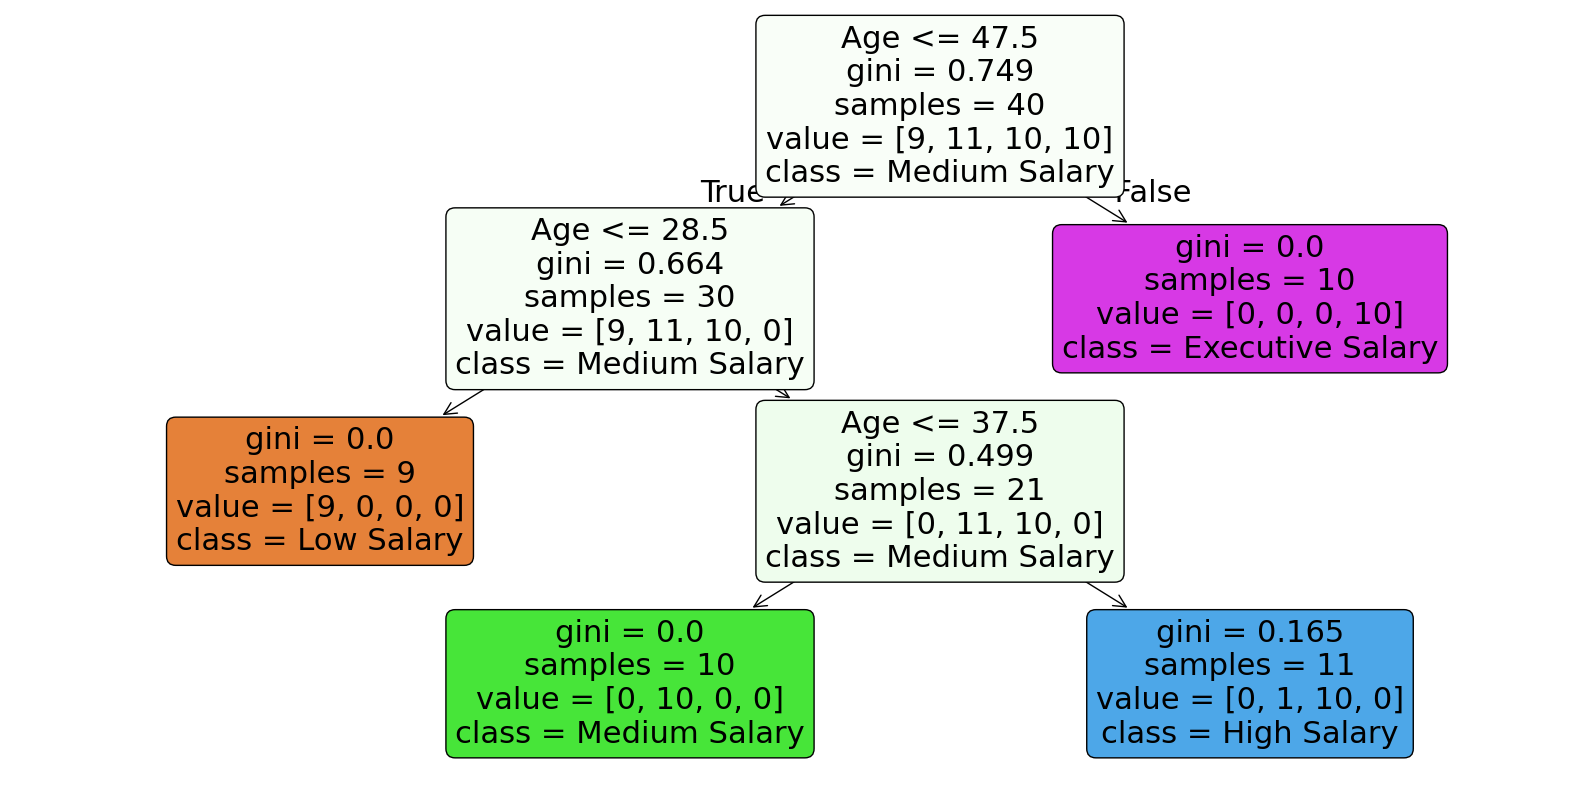

Decision Tree Generated Successfully


In [38]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[
        "Low Salary",
        "Medium Salary",
        "High Salary",
        "Executive Salary"
    ],
    filled=True,
    rounded=True
)

plt.show()

print("Decision Tree Generated Successfully")

**Conclusion**

In this notebook, a Decision Tree Classification model was successfully developed to classify employees into one of four salary categories. The dataset was preprocessed by handling missing values and splitting it into training and testing sets. The trained model was then used to predict salary categories for new employees. Finally, the model's performance was evaluated using accuracy, a confusion matrix, and a classification report. The Decision Tree was also visualized to better understand how it makes classification decisions.